<a href="https://colab.research.google.com/github/GermanOmar/GFRBC-SiC/blob/master/SiC_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effect of the Addition of SiC Particles on the Mechanical Performance of a Glass Fiber Reinforced Bio-Epoxy (GFRBC): Experimental Analysis and Machine Learning Modeling


## Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import preprocessing
import warnings
warnings.filterwarnings("ignore")

In [2]:
#---------Scikit-learn Utilities---------------------------------------------------------------------------------------------
from sklearn.metrics import r2_score as R2
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor

In [3]:
pip install nbformat


In [4]:
!pip install lazypredict
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.8 MB/s eta 0:00:00


## Upload database:

In [5]:
!git clone https://github.com/GermanOmar/GFRBC-SiC

Cloning into 'GFRBC-SiC'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.


In [6]:
#Experimental data
data = pd.read_table('/content/GFRBC-SiC/UTS.txt')
data.describe()

,SIC,UTS
count,66.000000,66.000000
mean,0.909091,242.387015
std,0.703339,18.839850
min,0.000000,197.320000
25%,0.500000,233.231025
50%,0.950000,245.676250
75%,1.475000,256.992600
max,2.000000,271.100000


In [7]:
df = data.copy()
df.head()

,SIC,UTS
0,0.0,218.37
1,0.0,220.63
2,0.0,205.23
3,0.0,202.37
4,0.0,208.79


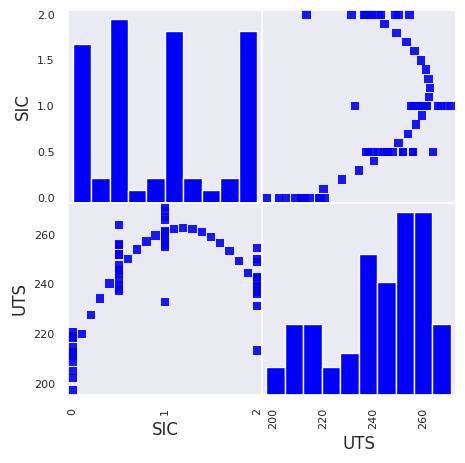

In [8]:
from pandas.plotting import scatter_matrix
#DISPLAY MATRIX - identificar correlacion entre variables
import seaborn as sns
sns.set()

plt.rcParams["axes.grid"] = False

#pd.tools.plotting.scatter_matrix(df, alpha=0.2, c='red', hist_kwds={'color':['burlywood']})

#scatter_matrix(data, alpha=0.2, marker='o', figsize = (12,12), color = 'blue')
scatter_matrix(data, alpha=0.9,marker='s', figsize = (5,5),  c='blue', hist_kwds={'color':['blue']})

warnings.filterwarnings("ignore")

##Setting inputs - output:

In [9]:
X=data[['SIC']]
Y=data['UTS'].values.reshape(-1, 1)


## Split data

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('training samples:', X_train.shape[0],  ' test samples:', X_test.shape[0])

training samples: 52  test samples: 14


In [11]:
YTR=np.mean(y_train)
YTR

np.float64(242.47034615384615)

In [12]:
YT=np.mean(y_test)
YT

np.float64(242.07749999999996)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle

In [15]:
from sklearn.metrics import mean_absolute_error as MAE
reg = LazyRegressor(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

                               Adjusted R-Squared   R-Squared        RMSE  \
Model                                                                       
KNeighborsRegressor                      0.793425    0.809316    9.106257   
GaussianProcessRegressor                 0.780104    0.797019    9.395293   
ExtraTreesRegressor                      0.771024    0.788637    9.587308   
BaggingRegressor                         0.768769    0.786556    9.634383   
RandomForestRegressor                    0.748823    0.768145   10.041320   
ExtraTreeRegressor                       0.745768    0.765325   10.102204   
XGBRegressor                             0.745260    0.764855   10.112297   
GradientBoostingRegressor                0.743804    0.763511   10.141160   
DecisionTreeRegressor                    0.743696    0.763411   10.143298   
AdaBoostRegressor                        0.635678    0.663703   12.093271   
SVR                                      0.422653    0.467064   15.223680   

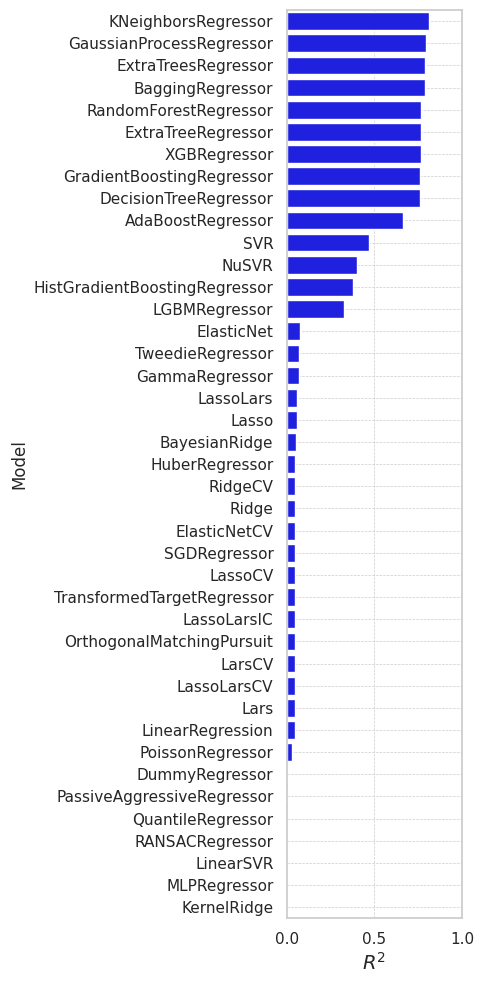

In [16]:
# Plotting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

import seaborn as sns
import matplotlib.pyplot as plt

# Re-defining models for independent execution
from lazypredict.Supervised import LazyRegressor
reg = LazyRegressor(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = reg.fit(X_train, X_test, y_train, y_test)


plt.style.use('seaborn-v0_8-white')
sns.set_theme(style="whitegrid")

# Corrected to use 'models' DataFrame and apply filtering to 'R-Squared'
models["R-Squared_filtered"] = [0 if i < 0 else i for i in models["R-Squared"] ]
plt.figure(figsize=(5, 10))
ax = sns.barplot(y=models.index, x="R-Squared_filtered", data=models, color='blue') # Changed to use 'models' and the new filtered column
ax.set(xlim=(0, 1))
plt.xlabel('$R^2$', fontsize=14)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.savefig('lazy1.png', dpi=300)

plt.show()

# KNN


In [18]:
from sklearn.neighbors import KNeighborsRegressor
#KERNEL
KNN=KNeighborsRegressor(n_neighbors=7)

#START TRAINING
KNN.fit(X_train,y_train)
#PREDICTION

y_train_pred = KNN.predict(X_train)
y_test_pred = KNN.predict(X_test)

y_pred_train = KNN.predict(X_train)
y_pred_test = KNN.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=5.6989, MSE=53.7685, R2=0.8353
Testing: MAE=7.2475, MSE=111.4318, R2=0.7438
----------------------------------------------------------------------------------------------------


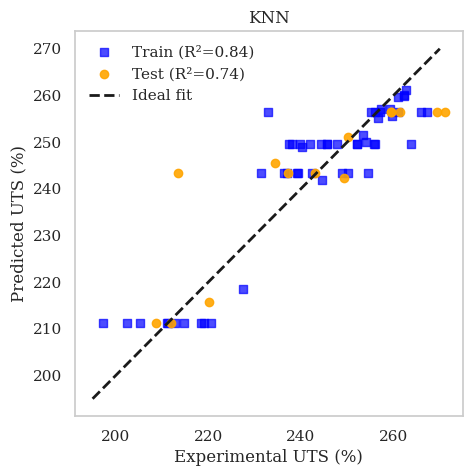

In [19]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='blue', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
ax.plot([195, 270], [195, 270], 'k--', lw=2, label='Ideal fit')
#ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("KNN")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='upper left')
ax.grid(False)
plt.show()

# Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor
#KERNEL
RFR=RandomForestRegressor(n_estimators=2000)

#START TRAINING
RFR.fit(X_train,y_train)
#PREDICTION

y_train_pred = RFR.predict(X_train)
y_test_pred = RFR.predict(X_test)

y_pred_train = RFR.predict(X_train)
y_pred_test = RFR.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=5.0244, MSE=49.2863, R2=0.8491
Testing: MAE=6.4458, MSE=97.9733, R2=0.7747
----------------------------------------------------------------------------------------------------


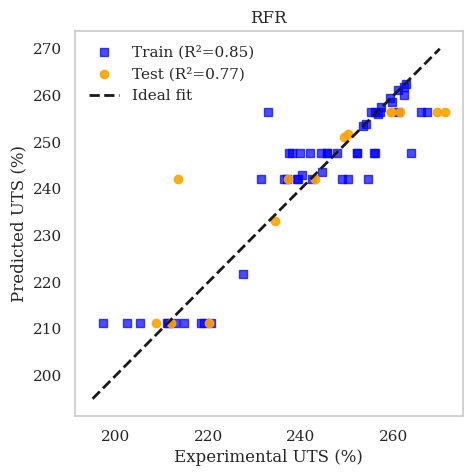

In [21]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='blue', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
#ax.plot([190, 260], [190, 260], 'k--', lw=2, label='Ideal fit')
ax.plot([195, 270], [195, 270], 'k--', lw=2, label='Ideal fit')

ax.set_title("RFR")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='upper left')
ax.grid(False)

plt.show()

# Gaussian Process Regressor

In [22]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
kernel = C(1.0, (1e-2, 1e2)) * RBF(10, (1e-2, 1e2))

GP=GPR(kernel=kernel, n_restarts_optimizer=20, alpha=0.001, normalize_y=True)

#START TRAINING
GP.fit(X_train, y_train)
#PREDICTION
y_train_pred = GP.predict(X_train)
y_test_pred = GP.predict(X_test)

y_pred_train = GP.predict(X_train)
y_pred_test = GP.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=4.7804, MSE=48.3613, R2=0.8519
Testing: MAE=6.0365, MSE=93.5225, R2=0.7849
----------------------------------------------------------------------------------------------------


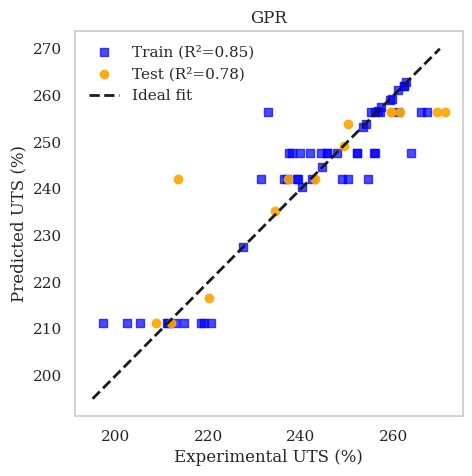

In [23]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='blue', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
ax.plot([195, 270], [195, 270], 'k--', lw=2, label='Ideal fit')

ax.set_title("GPR")
ax.set_xlabel("Experimental UTS (%)")
ax.set_ylabel("Predicted UTS (%)")


ax.legend(loc='upper left')
ax.grid(False)

plt.show()

# Cross-validation

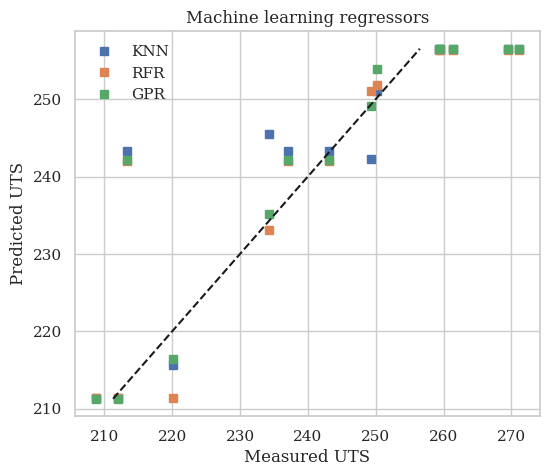

In [24]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

y1=KNN.predict(X_test)
y2=RFR.predict(X_test)
y3=GP.predict(X_test)

#Plots
models = [ KNN, RFR, GP]
labels = ['KNN', 'RFR', 'GPR']

fig = plt.figure()
fig.set_size_inches((6,5))

for mod, label in zip( models, labels):
  y_pred = mod.predict(X_test)
  plt.plot(y_test, y_pred, 's' ,label = label)

plt.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], 'k--')

plt.legend()

plt.ylabel('Predicted UTS')
plt.xlabel('Measured UTS')
plt.title("Machine learning regressors")
print()

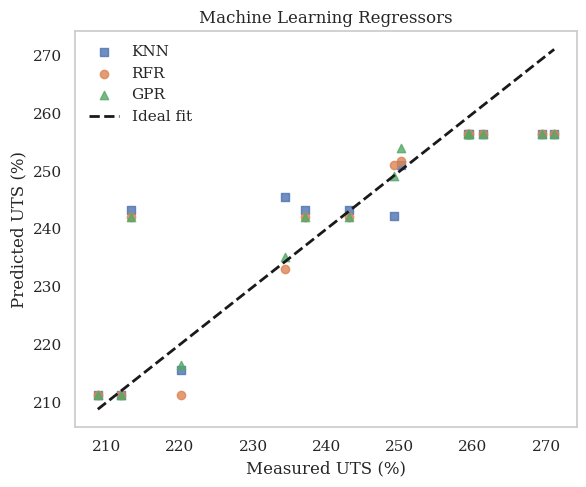

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

models = [KNN, RFR, GP]
labels = ['KNN', 'RFR', 'GPR']
markers = ['s', 'o', '^']

fig, ax = plt.subplots(figsize=(6,5))

for model, label, marker in zip(models, labels, markers):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, marker=marker, label=label, alpha=0.8)

# Línea de ajuste ideal
lims = [
    min(y_test.min(), *(model.predict(X_test).min() for model in models)),
    max(y_test.max(), *(model.predict(X_test).max() for model in models))
]
ax.plot(lims, lims, 'k--', lw=2, label='Ideal fit')

ax.set_xlabel('Measured UTS (%)')
ax.set_ylabel('Predicted UTS (%)')
ax.set_title('Machine Learning Regressors')

ax.legend()
ax.grid(False)      # Elimina el grid

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score as CV

import warnings
warnings.filterwarnings('ignore')

models = [ KNN, RFR, GP]
labels = ['KNN', 'RFR', 'GPR']
IMS = []

print("--------------------------------------------------------------")
print("%15s | %8s | %8s | %8s" % ("ML algorithm",  "CV-R2", "CV-MSE", "CV-MAE"))
print("--------------------------------------------------------------")

for mod, label in zip( models, labels):
  y_star_train = mod.predict(X_train)

  scoreR2 = CV(mod, X_train, y_train, cv=5, scoring='r2')
  #print(-1*scoreR2)
  scoreMSE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
  #print(-1*scoreMSE)
  scoreMAE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
  #print(-1*scoreMAE)

  print("%15s | %.4f | %.4f | %.4f" % (label,  scoreR2.mean(), -1*scoreMSE.mean(), -1*scoreMAE.mean() ))
print("--------------------------------------------------------------")

--------------------------------------------------------------
   ML algorithm |    CV-R2 |   CV-MSE |   CV-MAE
--------------------------------------------------------------
            KNN | 0.7746 | 65.3020 | 6.3391
            RFR | 0.7725 | 67.1459 | 6.1152
            GPR | 0.7775 | 63.5225 | 6.1714
--------------------------------------------------------------


# LOO

In [27]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------
# Assume your flex dataset is defined as:
# X = np.array([...]).reshape(-1, 1)  # TiO2 wt.%
# y = np.array([...])                 # Flexural strength (MPa)
# ----------------------------------------

loo = LeaveOneOut()

# Fix: Create a dictionary for models using labels and the models list
models_dict = dict(zip(labels, models))

results = {}

for name, model in models_dict.items():
    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(X):

        # Split data
        X_train_loo, X_test_loo = X.iloc[train_idx], X.iloc[test_idx]
        y_train_loo, y_test_loo = Y[train_idx], Y[test_idx]

        # Standardize INSIDE CV loop (avoid leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_loo)
        X_test_scaled = scaler.transform(X_test_loo)

        # Fit model
        # Reshape y_train_loo to be 1D for models like MLPRegressor
        if y_train_loo.ndim > 1 and y_train_loo.shape[1] == 1:
            model.fit(X_train_scaled, y_train_loo.ravel())
        else:
            model.fit(X_train_scaled, y_train_loo)

        # Predict
        prediction = model.predict(X_test_scaled)

        y_true.append(y_test_loo[0])
        y_pred.append(prediction[0])

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "R2": r2}

# Print results
for model_name, metrics in results.items():
    print(f"{model_name} LOOCV Results:")
    print(f"  MAE: {metrics['MAE']:.3f}")
    print(f"  MSE: {metrics['MSE']:.3f}")
    print(f"  R2 : {metrics['R2']:.3f}")
    print("-" * 40)


KNN LOOCV Results:
  MAE: 6.504
  MSE: 73.903
  R2 : 0.789
----------------------------------------
RFR LOOCV Results:
  MAE: 5.662
  MSE: 67.486
  R2 : 0.807
----------------------------------------
GPR LOOCV Results:
  MAE: 5.212
  MSE: 64.165
  R2 : 0.816
----------------------------------------


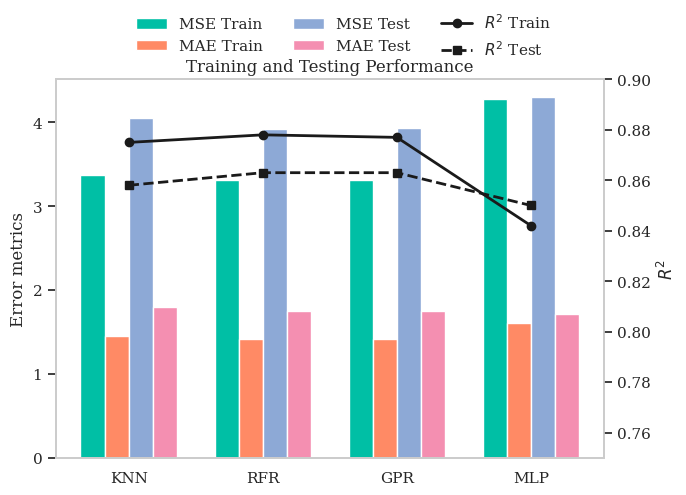

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

models = ['KNN','RFR','GPR']

MAE_train = [1.451,1.420,1.419]
MSE_train = [1.451,1.420,1.419]
R2_train  = [1.451,1.420,1.419]

MAE_test = [1.451,1.420,1.419]
MSE_test = [1.451,1.420,1.419]
R2_test  = [1.451,1.420,1.419]

x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(7,5))

ax.bar(x-1.5*width, MSE_train, width,
       label='MSE Train', color='#00bfa5')

ax.bar(x-0.5*width, MAE_train, width,
       label='MAE Train', color='#ff8a65')

ax.bar(x+0.5*width, MSE_test, width,
       label='MSE Test', color='#8da9d6')

ax.bar(x+1.5*width, MAE_test, width,
       label='MAE Test', color='#f48fb1')

ax.set_ylabel('Error metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)

ax2 = ax.twinx()

ax2.plot(x,R2_train,'ko-',lw=2,label='$R^2$ Train')
ax2.plot(x,R2_test,'ks--',lw=2,label='$R^2$ Test')

ax2.set_ylabel(r'$R^2$')
ax2.set_ylim(0.75,0.90)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(handles1+handles2,
           labels1+labels2,
           ncol=3,
           loc='upper center')

plt.title('Training and Testing Performance')
plt.tight_layout(rect=[0,0,1,0.92])

plt.show()